<a href="https://colab.research.google.com/github/io-uty/skt-bigdata-analysis/blob/main/11_DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Deep Neural Network

In [ ]:
import numpy as np

X = np.array([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0])
y = np.array([5.0, 6.0, 7.0, 8.0, 9.0, 10.0])

print(X.shape, y.shape)

(6,) (6,)


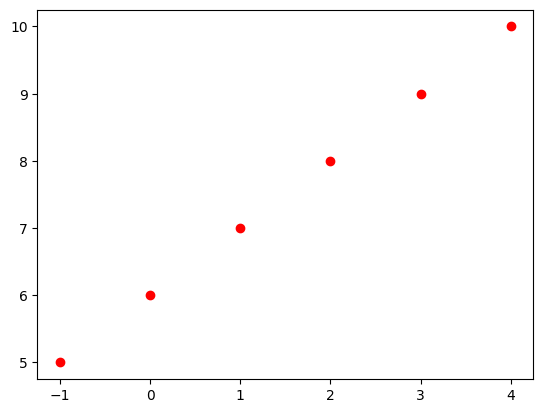

In [ ]:
import matplotlib.pyplot as plt

plt.plot(X, y, 'ro')
plt.show()

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(1, input_shape=(1,)),
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='sgd', loss='mse', metrics=['mae'])

In [ ]:
history = model.fit(X,y,epochs=30, verbose=1)

Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 619ms/step - loss: 29.6221 - mae: 5.3995
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 26.6899 - mae: 5.0836
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 24.3135 - mae: 4.8003
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 22.3757 - mae: 4.5460
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - loss: 20.7844 - mae: 4.3175
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - loss: 19.4672 - mae: 4.1119
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 18.3669 - mae: 3.9266
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 17.4385 - mae: 3.7593
Epoch 9/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 16.6468 - mae: 3.6081
Epoch 10/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 15.9637 - mae: 3.4712
Epoch 11/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 15.3674 - mae: 3.3469
Epoch 12/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 14.8406 - mae: 3.2340
Epoch 13/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57

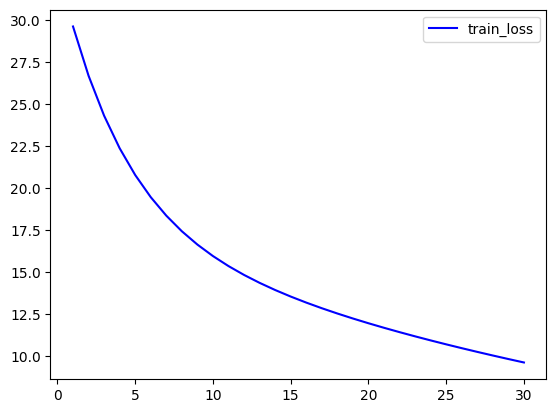

In [ ]:
import matplotlib.pyplot as plt

loss = history.history['loss']
epochs = range(1, len(loss)+1)

plt.plot(epochs, loss, color='blue', label='train_loss')
plt.xlabel = ('epochs')
plt.ylabel = ('loss')
plt.legend()
plt.show()

In [ ]:
X_test = np.array([[10.0]])
y_pred = model.predict(X_test)
print(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
[[24.65661]]


In [ ]:
w,b = model.get_weights()
print('w : ', w)
print('b : ', b)

w :  [[2.2735305]]
b :  [1.9213047]


In [ ]:
y_pred = model.predict(X.reshape(-1, 1))
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


array([[-0.35222578],
       [ 1.9213047 ],
       [ 4.194835  ],
       [ 6.4683657 ],
       [ 8.741896  ],
       [11.015427  ]], dtype=float32)

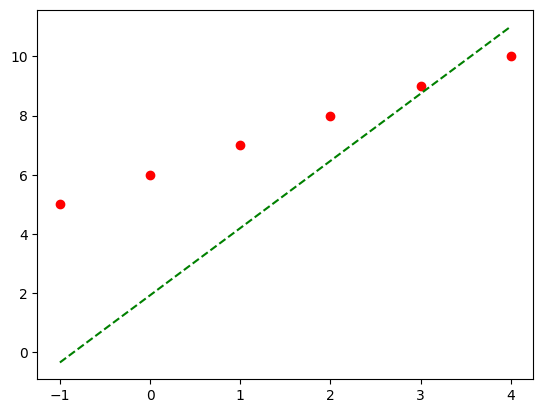

In [ ]:
plt.plot(X,y,'ro')
plt.plot(X,y_pred,'g--')
plt.show()

# 2. 다중 선형회귀

https://gist.githubusercontent.com/wmeints/80c1ba22ceeb7a29a0e5e979f0b0afba/raw/8629fe51f0e7642fc5e05567130807b02a93af5e/auto-mpg.csv

In [ ]:
import pandas as pd

mpg = pd.read_csv('./auto-mpg.csv', na_values = "?")
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


In [ ]:
mpg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(4), int64(4), object(1)
memory usage: 28.1+ KB


In [ ]:
mpg.isna().sum(axis=0)

,0
mpg,0
cylinders,0
displacement,0
horsepower,6
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [ ]:
df = mpg[mpg['horsepower'].isna()]
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
32,25.0,4,98.0,NaN,2046,19.0,71,1,ford pinto
126,21.0,6,200.0,NaN,2875,17.0,74,1,ford maverick
330,40.9,4,85.0,NaN,1835,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,NaN,2905,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,NaN,2320,15.8,81,2,renault 18i
374,23.0,4,151.0,NaN,3035,20.5,82,1,amc concord dl


In [ ]:
mpg = mpg.dropna()
mpg.isna().sum(axis=0)

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
model year,0
origin,0
car name,0


In [ ]:
X_data=mpg.drop(['mpg', 'car name'], axis=1)
X_data.head()

,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,8,307.0,130.0,3504,12.0,70,1
1,8,350.0,165.0,3693,11.5,70,1
2,8,318.0,150.0,3436,11.0,70,1
3,8,304.0,150.0,3433,12.0,70,1
4,8,302.0,140.0,3449,10.5,70,1


In [ ]:
y_data = mpg['mpg']
y_data.head()

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(313, 7) (79, 7)
(313,) (79,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(X_train_s[:5])

[[ 0.30486156  0.28457757  0.14142863  0.75480297  1.1217589   0.49452752
  -0.68982474]
 [-0.87318372 -0.53588042 -0.32949862 -0.49312922 -0.22893966 -0.0572982
  -0.68982474]
 [ 0.30486156 -0.23665456 -0.19868549 -0.00252992 -0.37111846 -0.33321105
  -0.68982474]
 [ 1.48290683  1.18225513  1.18793363  1.3680521  -0.72656545 -1.16094962
  -0.68982474]
 [-0.87318372 -1.05711255 -1.06205212 -1.32309939  0.30423083  1.32226608
  -0.68982474]]


In [ ]:
y_train = y_train.values
y_test = y_test.values

print(type(y_train), type(y_test))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(64, activation='relu',input_shape=(7,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='mse', optimizer='adam',
              metrics=['mae','mse'])

In [ ]:
EPOCHS = 200
BATCH_SIZE = 32
history = model.fit(X_train_s, y_train,
epochs=EPOCHS,
batch_size=BATCH_SIZE,
validation_split = 0.2,
verbose=1)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 606.2385 - mae: 23.3507 - mse: 606.2385 - val_loss: 672.4324 - val_mae: 24.7648 - val_mse: 672.4324
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 580.3682 - mae: 22.7998 - mse: 580.3682 - val_loss: 645.1812 - val_mae: 24.2183 - val_mse: 645.1812
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 553.4243 - mae: 22.2063 - mse: 553.4243 - val_loss: 613.1671 - val_mae: 23.5688 - val_mse: 613.1671
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 520.4254 - mae: 21.4771 - mse: 520.4254 - val_loss: 573.9841 - val_mae: 22.7511 - val_mse: 573.9841
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 480.7495 - mae: 20.5554 - mse: 480.7495 - val_loss: 524.5538 - val_mae: 21.6851 - val_mse: 524.5538
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 430.4630 - mae: 19.3515 - mse: 430.4630 - val_loss: 463.8411 - val_mae: 20.3090 - val_mse: 463.8411
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - 

In [ ]:
history.history.keys()


dict_keys(['loss', 'mae', 'mse', 'val_loss', 'val_mae', 'val_mse'])

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch
  plt.figure(figsize=(16,8))
  plt.subplot(1,2,1)
  # plt.xlabel('Epoch')
  # plt.ylabel('Mean Abs Error [MPG]')
  plt.plot(hist['epoch'], hist['mae'], label='Train Error')
  plt.plot(hist['epoch'], hist['val_mae'], label = 'Val Error')
  plt.ylim([0,5])
  plt.legend()

  plt.subplot(1,2,2)
  # plt.xlabel('Epoch')
  # plt.ylabel('Mean Square Error [$MPG^2$]')
  plt.plot(hist['epoch'], hist['mse'], label='Train Error')
  plt.plot(hist['epoch'], hist['val_mse'], label = 'Val Error')
  plt.ylim([0,20])
  plt.legend()
  plt.show()

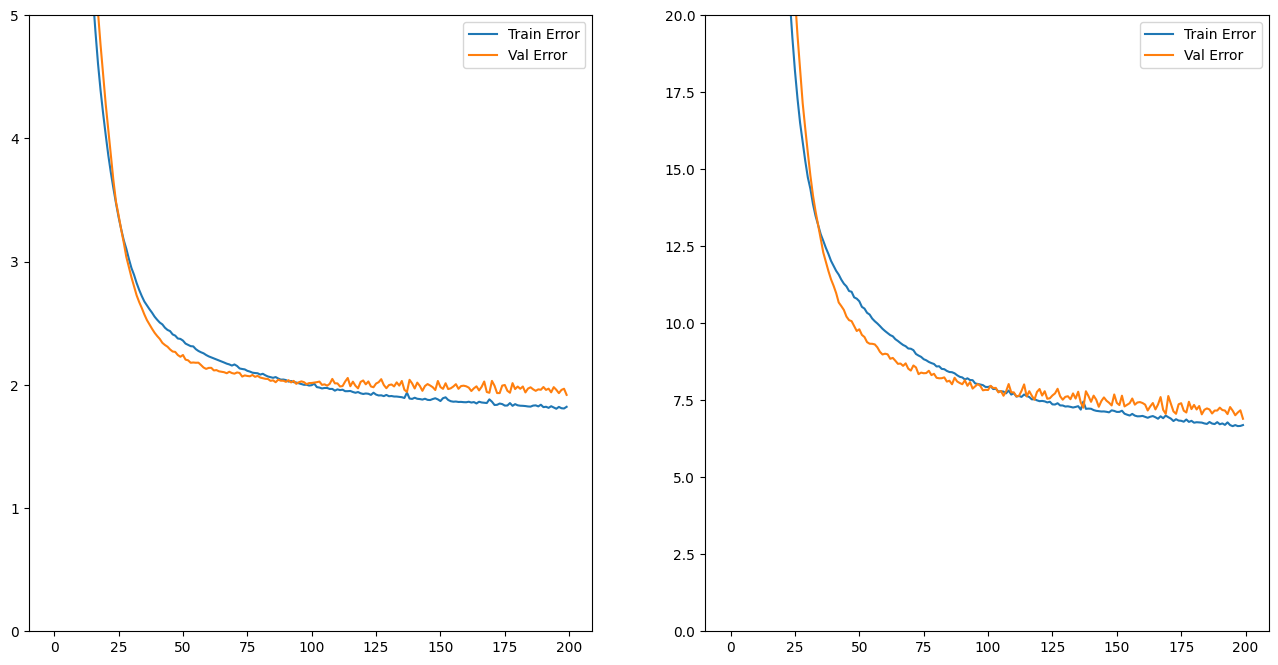

In [ ]:
plot_history(history)

In [ ]:
loss, mae, mse = model.evaluate(X_test_s, y_test, verbose=2)

3/3 - 0s - 79ms/step - loss: 6.7734 - mae: 1.8007 - mse: 6.7734


In [ ]:
y_pred = model.predict(X_test_s)
y_pred

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step


array([[24.738087 ],
       [21.04489  ],
       [35.33243  ],
       [25.673525 ],
       [29.080368 ],
       [29.727097 ],
       [13.51669  ],
       [30.880621 ],
       [18.425554 ],
       [30.676825 ],
       [15.172721 ],
       [20.812983 ],
       [17.78912  ],
       [28.554712 ],
       [16.352255 ],
       [30.284208 ],
       [18.248852 ],
       [34.227215 ],
       [28.817602 ],
       [27.726812 ],
       [20.045725 ],
       [42.778027 ],
       [36.79761  ],
       [16.42676  ],
       [29.248182 ],
       [23.519922 ],
       [17.905676 ],
       [17.50633  ],
       [30.024855 ],
       [21.168749 ],
       [14.334688 ],
       [20.520887 ],
       [19.893026 ],
       [33.644444 ],
       [14.341691 ],
       [38.17874  ],
       [14.073153 ],
       [25.363691 ],
       [13.160477 ],
       [11.145381 ],
       [14.507354 ],
       [27.016357 ],
       [35.01253  ],
       [26.23562  ],
       [14.657716 ],
       [12.954107 ],
       [18.072802 ],
       [32.10

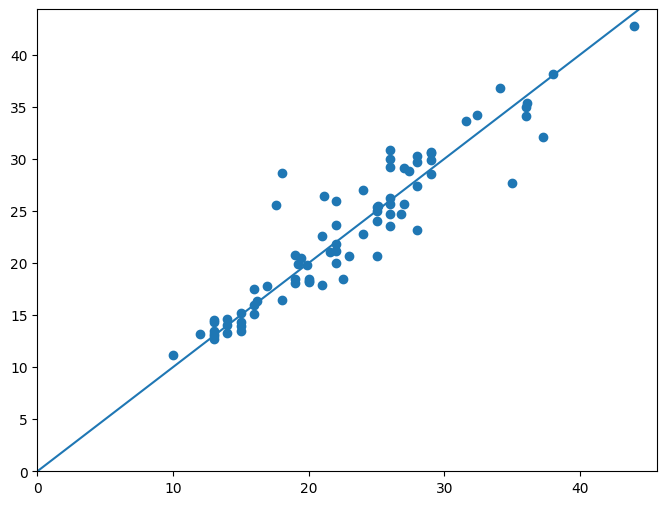

In [ ]:
y_pred = y_pred.flatten()
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
# plt.xlabel('True Values [MPG]')
# plt.ylabel('Predictions [MPG]')
plt.xlim([0,plt.xlim()[1]])
plt.ylim([0,plt.ylim()[1]])
plt.plot([-100, 100], [-100, 100])
plt.show()

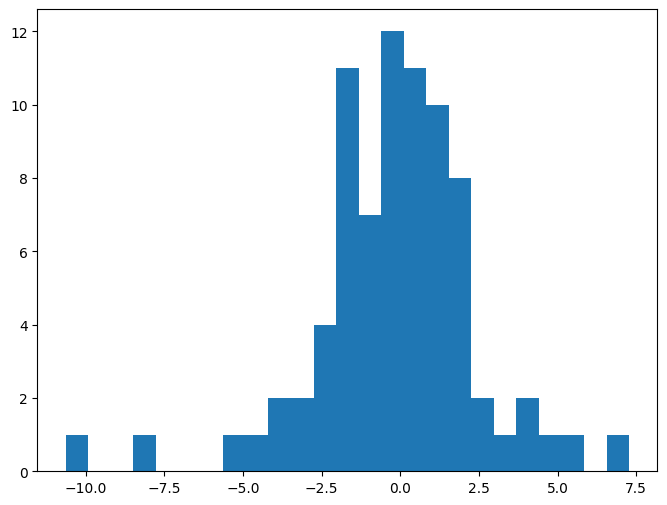

In [ ]:
error = y_test - y_pred
plt.figure(figsize=(8,6))
plt.hist(error, bins = 25)
# plt.xlabel("Prediction Error [MPG]")
# plt.ylabel("Count")
plt.show()